In [3]:
# Load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option("display.max_colwidth", 200)
sns.set(style="whitegrid")


In [6]:
import os
print(os.getcwd())


c:\Users\USER\Desktop\spam_detection\notebooks\FC212033-Naveena


In [7]:
# Load dataset
df = pd.read_csv("maildata.csv")

df.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [8]:
# Basic dataset overview
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Rename columns for consistency (optional but cleaner)
df = df.rename(columns={"Category": "label", "Message": "text"})

# Remove duplicates
df = df.drop_duplicates()

# Display updated info
df.info()
df.head()


Shape: (5572, 2)

Columns: ['Category', 'Message']

Missing values:
Category    0
Message     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5157 non-null   object
 1   text    5157 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB


,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


label
ham     4516
spam     641
Name: count, dtype: int64


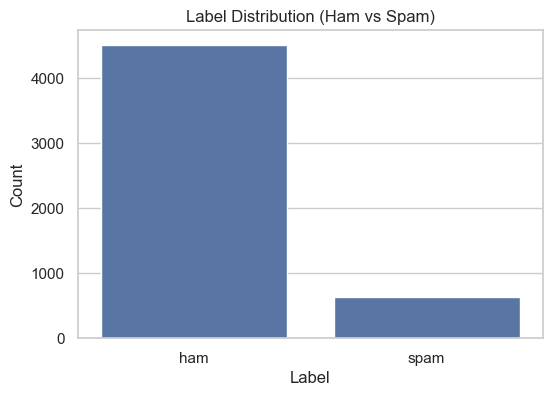

In [9]:
# Count of labels
label_counts = df['label'].value_counts()

print(label_counts)

# Plot label distribution
plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Label Distribution (Ham vs Spam)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


In [10]:
df["text_length"] = df["text"].apply(len)
df.head()


,label,text,text_length
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives around here though",61


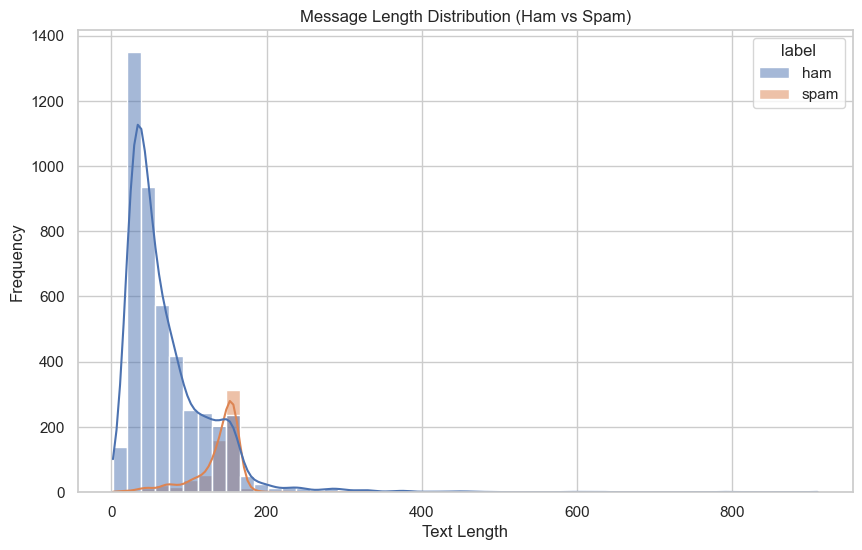

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="text_length", hue="label", bins=50, kde=True)
plt.title("Message Length Distribution (Ham vs Spam)")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Features and labels
X = df["text"]
y = df["label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words="english")

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape


((4125, 7407), (1032, 7407))

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train SVM (Linear kernel works best for text classification)
svm_clf = SVC(kernel="linear", C=1.0)
svm_clf.fit(X_train_tfidf, y_train)

# Predictions
y_pred = svm_clf.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9777131782945736

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      0.99      0.99       904
        spam       0.96      0.86      0.91       128

    accuracy                           0.98      1032
   macro avg       0.97      0.93      0.95      1032
weighted avg       0.98      0.98      0.98      1032


Confusion Matrix:
 [[899   5]
 [ 18 110]]


In [14]:
import joblib

# Save model and vectorizer
joblib.dump(svm_clf, "svm_spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!
